# Assignment 2 - Image Captioning using CNNs and LSTMs

For this assignemnt, you will be given full-colour images as input data, and attempt to develop an Encoder-Decoder model to create worded captions for the image. For instance, for the image 

<img src='https://towardsdatascience.com/wp-content/uploads/2022/06/0HxBDFFqwpjShEnyb-scaled.jpg' width='250px'/>

Your model may generate something like "A dog running in the sea"


We will work with the Flickr8k dataset, which contains 8000 images, each associated with 5 sample captions.

## Flickr8k Dataset

This dataset contains approximately 1GB of data. Therefore it is strongly reccommended to use the UCC Jupyter server for this assignment.

In [1]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [2]:
!mkdir -p data/flickr8k/
!wget "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip" -O "data/flickr8k/Flickr8k_Dataset.zip"
!wget "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip" -O "data/flickr8k/Flickr8k_text.zip"

--2026-03-25 10:30:23--  https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
Resolving github.com (github.com)... 4.208.26.197
Connecting to github.com (github.com)|4.208.26.197|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/124585957/47f52b80-3501-11e9-8f49-4515a2a3339b?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-25T11%3A26%3A49Z&rscd=attachment%3B+filename%3DFlickr8k_Dataset.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-25T10%3A25%3A59Z&ske=2026-03-25T11%3A26%3A49Z&sks=b&skv=2018-11-09&sig=pj8GDoEGRPVhNULAPQqVIuRHuGN7%2F0we9hXy5VhgaZo%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NDQzODIyMywibmJmIjoxNzc0NDM0NjIzLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZ

In [3]:
%%bash
if [ ! -d "data/flickr8k/Flicker8k_Dataset" ]
then
    unzip "data/flickr8k/Flickr8k_Dataset.zip" -d data/flickr8k/
fi

if [ ! -d "data/flickr8k/Flickr8k_text" ]
then
    unzip "data/flickr8k/Flickr8k_text.zip" -d data/flickr8k/Flickr8k_text
    rm -r "data/flickr8k/Flickr8k_text/__MACOSX"
fi

if [ -d "data/flickr8k/__MACOSX" ]
then
    rm -r "data/flickr8k/__MACOSX"
fi
mkdir -p saved_models

## Data Loading

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import os
import numpy as np

from collections import Counter

import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader,Dataset
import torchvision.transforms as T

from PIL import Image


You may ned to use `%cd __wherever__` here

In [5]:
data_location =  "data/flickr8k"

caption_file = data_location + '/Flickr8k_text/Flickr8k.token.txt'
df = pd.read_csv(caption_file, delimiter='\t', header=None)

# Cleanup filenames
df.iloc[:,0] = df[0].apply(lambda x: x.split('#')[0])
df = df[~df[0].apply(lambda x: '.jpg.1' in x)]

print("There are {} unique captions".format(len(df)))


There are 40455 unique captions


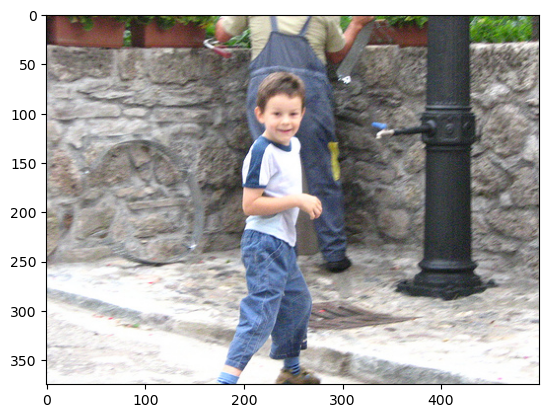

Caption: A boy smiles in front of a stony wall in a city .
Caption: A little boy is standing on the street while a man in overalls is working on a stone wall .
Caption: A young boy runs aross the street .
Caption: A young child is walking on a stone paved street with a metal pole and a man behind him .
Caption: Smiling boy in white shirt and blue jeans in front of rock wall with man in overalls behind him .


In [6]:
data_idx = 42

image_path = data_location+"/Flicker8k_Dataset/"+df.iloc[data_idx,0]
img=mpimg.imread(image_path)
plt.imshow(img)
plt.show()

all_captions=df[1][df[0]==df.iloc[data_idx,0]]

for cap in all_captions:
    print("Caption:",cap)

## Creating PyTorch Dataset

### Tokenization

The first step is to splitthe captions into uniformly formatted lists of 'tokens', which act as the inputs to our models. Tokens can be words or punctuation, which are used similarly as how we used characters in the previous lab.

In order to clean up the text, we will use the Python SpaCY NLP module

In [7]:
#%pip install spacy
%pip install "spacy==3.8.11"

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [8]:
!python -m spacy download en_core_web_sm

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 105.3 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [9]:
import spacy

In [10]:
!python -m spacy info%pip install "spacy==3.8.11"

Usage: python -m spacy [OPTIONS] COMMAND [ARGS]...
Try 'python -m spacy --help' for help.
╭─ Error ──────────────────────────────────────────────────────────────────────╮
│ No such command 'info%pip'. Did you mean 'info'?                             │
╰──────────────────────────────────────────────────────────────────────────────╯


In [11]:
spacy_eng = spacy.load("en_core_web_sm")

We will use this to split sentences into "tokens", which we will pass as inputs to our models.

In [12]:
text = "This is a good place - to find a city!"
[token.text.lower() for token in spacy_eng.tokenizer(text)]

['this', 'is', 'a', 'good', 'place', '-', 'to', 'find', 'a', 'city', '!']

### Vocabulary

We will map every possible 'token' that we encounter into a distinct integer.

In [13]:
class Vocabulary:
    def __init__(self,freq_threshold):
        #setting the pre-reserved tokens int to string tokens
        self.itos = {0:"<PAD>",1:"<SOS>",2:"<EOS>",3:"<UNK>"}
        
        #string to int tokens
        #its reverse dict self.itos
        self.stoi = {v:k for k,v in self.itos.items()}
        
        self.freq_threshold = freq_threshold
        
    def __len__(self): return len(self.itos)
    
    @staticmethod
    def tokenize(text):
        return [token.text.lower() for token in spacy_eng.tokenizer(text)]
    
    def build_vocab(self, sentence_list):
        frequencies = Counter()
        idx = 4
        
        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1
                
                #add the word to the vocab if it reaches minum frequecy threshold
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1
    
    def numericalize(self,text):
        """ For each word in the text corresponding index token for that word form the vocab built as list """
        tokenized_text = self.tokenize(text)
        return [ self.stoi[token] if token in self.stoi else self.stoi["<UNK>"] for token in tokenized_text ] 

In [14]:
v = Vocabulary(freq_threshold=1)

v.build_vocab(["This is a good place - to find a city!"])
print(v.stoi)
print(v.numericalize("This is a good place ; to find a city here!"))

{'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3, 'this': 4, 'is': 5, 'a': 6, 'good': 7, 'place': 8, '-': 9, 'to': 10, 'find': 11, 'city': 12, '!': 13}
[4, 5, 6, 7, 8, 3, 10, 11, 6, 12, 3, 13]


Notice how ';' and 'here' are unknown tokens, which our volcabularly maps to \<UNK\> -- unkown. \<SOS\> and \<EOS\> Correpsond to Start and End of Sentence

### Dataset

There are ~40000 samples. We will use 30000 samples for training, and the remainder for validation.

In [15]:
class FlickrDataset(Dataset):
    """
    FlickrDataset
    """
    def __init__(self,root_dir,captions_file,transform=None,train=True,freq_threshold=5):
        self.root_dir = root_dir
        self.df = pd.read_csv(caption_file, delimiter='\t', header=None)
        # Cleanup filenames
        np.random.seed(42)
        self.df = self.df.sample(frac=1)
        
        self.df =  self.df.reset_index(drop=True)
        self.df.iloc[:,0] = self.df[0].apply(lambda x: x.split('#')[0])
        self.df = self.df[~self.df[0].apply(lambda x: '.jpg.1' in x)]
        self.df =self.df.reset_index()
        self.transform = transform
        
        #Get image and caption colum from the dataframe
        self.imgs = self.df[0]
        self.captions = self.df[1]
        
        #Initialize vocabulary and build vocab
        self.vocab = Vocabulary(freq_threshold)
        self.vocab.build_vocab(self.captions.tolist())
        
        if train:
            self.df = self.df.iloc[:30000,:]
        else:
            self.df = self.df.iloc[30000:,:]
        
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self,idx):
        caption = self.captions[idx]
        img_name = self.imgs[idx]
        img_location = os.path.join(self.root_dir,img_name)
        img = Image.open(img_location).convert("RGB")
        
        #apply the transfromation to the image
        if self.transform is not None:
            img = self.transform(img)
        
        #numericalize the caption text
        caption_vec = []
        caption_vec += [self.vocab.stoi["<SOS>"]]
        caption_vec += self.vocab.numericalize(caption)
        caption_vec += [self.vocab.stoi["<EOS>"]]
        
        return img, torch.tensor(caption_vec)

In [16]:
'''def get_mean_std(loader):
    # Sum of pixels and sum of squared pixels for each channel
    channels_sum, channels_squared_sum, num_batches = 0, 0, 0
    
    for data, _ in loader:
        # data shape: [batch_size, 3, height, width]
        channels_sum += torch.mean(data, dim=[0, 2, 3])
        channels_squared_sum += torch.mean(data**2, dim=[0, 2, 3])
        num_batches += 1
    
    mean = channels_sum / num_batches
    std = (channels_squared_sum / num_batches - mean**2)**0.5
    return mean, std

get_mean_std(loader)
'''

'def get_mean_std(loader):\n    # Sum of pixels and sum of squared pixels for each channel\n    channels_sum, channels_squared_sum, num_batches = 0, 0, 0\n\n    for data, _ in loader:\n        # data shape: [batch_size, 3, height, width]\n        channels_sum += torch.mean(data, dim=[0, 2, 3])\n        channels_squared_sum += torch.mean(data**2, dim=[0, 2, 3])\n        num_batches += 1\n\n    mean = channels_sum / num_batches\n    std = (channels_squared_sum / num_batches - mean**2)**0.5\n    return mean, std\n\nget_mean_std(loader)\n'

In [17]:
# Downscale the images, convert to Tensor
transforms = T.Compose([
    T.Resize((224,224)),
    # These are the manually computed means and stdevs in each dimension
    T.ToTensor(),
    T.Normalize((0.485, 0.4461, 0.4039), (0.2695, 0.2623, 0.2772)),
    
])

In [18]:
train_dataset =  FlickrDataset(
    root_dir = data_location+"/Flicker8k_Dataset",
    captions_file = data_location+"/Flickr8k_text/Flickr8k.token.txt",
    transform=transforms
)

val_dataset =  FlickrDataset(
    root_dir = data_location+"/Flicker8k_Dataset",
    captions_file = data_location+"/Flickr8k_text/Flickr8k.token.txt",
    train=False,
    transform=transforms
)

In [19]:
def show_image(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001) 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7850778..2.1504326].


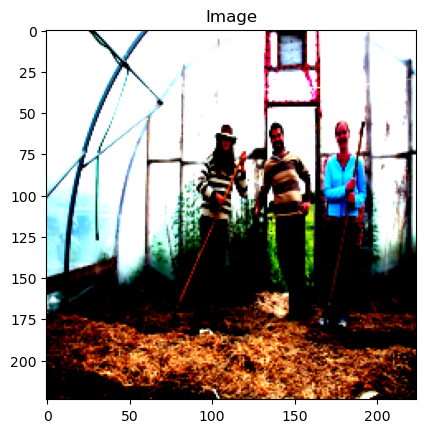

Token: tensor([   1,    4,    8,   20,   14,  107,   15,  206,    4, 2599,   36,    3,
        1478,    5,    2])
Sentence:
['<SOS>', 'a', 'man', 'and', 'two', 'women', 'are', 'inside', 'a', 'greenhouse', 'holding', '<UNK>', 'tools', '.', '<EOS>']


In [20]:
img, caps = train_dataset[0]
show_image(img,"Image")
print("Token:",caps)
print("Sentence:")
print([train_dataset.vocab.itos[token] for token in caps.tolist()])


### Dataloader

In oder to enable batching for our dataloader, we must pad our captions with dummy tokens to be of uniform length:

In [21]:
class PadCaptions:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)
        targets = [item[1] for item in batch]
        targets = pad_sequence(targets, batch_first=True, padding_value=self.pad_idx)

        return imgs, targets
    
pad_idx = train_dataset.vocab.stoi["<PAD>"]

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    collate_fn = PadCaptions(pad_idx=pad_idx)
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    collate_fn = PadCaptions(pad_idx=pad_idx)
)

/home/kjor1/.local/lib/python3.13/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [22]:
print(torch.cuda.is_available())

True


# Model Fitting

We will fit an Encoder-Decoder model, with a CNN as the encoder, and a LSTM as the Decoder.

<img src='https://towardsdatascience.com/wp-content/uploads/2022/06/1MqsV98FA4XA99QFs7BXldg.jpeg' width='500px'/>

The key thing to understand is the link bewteen the CNN output, and the RNN input:

<img src='https://learnopencv.com/wp-content/uploads/2024/12/encoder-decoder.png' />

Key:

# Task 1 CNN Encoder

In [102]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EncoderCNN(nn.Module):
    def __init__(self, embed_size):
        super(EncoderCNN, self).__init__()
        # Layer 1: Input (3, 224, 224) -> Output (32, 112, 112)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        #self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Layer 2: Output (64, 56, 56)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        #self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Layer 3: Output (128, 28, 28)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        #self.bn1 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        #self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        #self.pool4 = nn.MaxPool2d(2, 2)
        
        # Fully connected layer to reach embed_size
        # Assuming input image is 224x224, after 3 pools it is 28x28
        self.fc = nn.Linear(128 * 28 * 28, embed_size)
        #self.dropout = nn.Dropout(0.5)

    def forward(self, images):
        x = self.pool1(F.relu(self.conv1(images)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        #x = self.pool4(F.relu(self.conv4(x)))
        
        # Flatten the features
        x = x.view(x.size(0), -1) 
        x = F.relu(self.fc(x))
        return x

# Task 2 LSTM Decoder

`self.embedding = nn.Embedding(vocab_size, embed_size)`

Is an important component here.

Recall that last week, we created 1-hot vectors (of some length) to represent indivdual characters.

Here, we create a traianable layer that abstracts away this component. This takes in the number of possible tokens in our vocabulary, and outputs a fixed size (not necessarily 1-hot) vector of size embed_size.




In [103]:
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super(DecoderRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        #self.embed_dropout = nn.Dropout(0.3)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        #self.out_dropout   = nn.Dropout(0.3)
        self.linear = nn.Linear(hidden_size, vocab_size)

    # Features is passed from the CNN layer!
    def forward(self, features, captions):
        # Remove the <end> token from the caption for training
        embeddings = self.embedding(captions[:, :-1])       
        # Add the image features as the first 'word' of the sequence
        # features: (batch, embed_size) -> (batch, 1, embed_size)
        # Combine the CNN output, and the word embeddings, these become the inputs!
        embeddings = torch.cat((features.unsqueeze(1), embeddings), dim=1)
        
        hiddens, _ = self.lstm(embeddings)
        outputs = self.linear(hiddens)
        return outputs

### Defining the Full Model:


In [162]:
IMAGE_SIZE = 224
BATCH_SIZE = 128
EMBED_SIZE = 512
HIDDEN_SIZE = 1024
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vocab=train_dataset.vocab
VOCAB_SIZE = len(vocab)

encoder = EncoderCNN(EMBED_SIZE).to(DEVICE)
decoder = DecoderRNN(EMBED_SIZE, HIDDEN_SIZE, VOCAB_SIZE).to(DEVICE)



In [163]:
from tqdm import tqdm # For a nice progress bar


# Initialize Loss and Optimizer
# We ignore the <PAD> token in loss calculation so it doesn't penalize the model
criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<PAD>"])
params = list(encoder.parameters()) + list(decoder.parameters())
optimizer = torch.optim.Adam(params, lr=LEARNING_RATE)

# Move models to device
encoder.to(DEVICE)
decoder.to(DEVICE)

for epoch in range(1, NUM_EPOCHS + 1):
    # --- TRAINING PHASE ---
    encoder.train()
    decoder.train()
    train_loss = 0
    
    # Progress bar for the training loader
    loop = tqdm(train_loader, total=len(train_loader), leave=True)
    for images, captions in loop:
        images, captions = images.to(DEVICE), captions.to(DEVICE)

        # Forward pass
        optimizer.zero_grad()
        
        # Extract features from CNN and pass to RNN
        features = encoder(images)
        outputs = decoder(features, captions)

        # Calculate loss: 
        # outputs shape: (batch, seq_len, vocab_size)
        # targets shape: (batch, seq_len)
        # We flatten them to (batch * seq_len, vocab_size) for CrossEntropy
        loss = criterion(outputs.view(-1, VOCAB_SIZE), captions.view(-1))
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        loop.set_description(f"Epoch [{epoch}/{NUM_EPOCHS}]")
        loop.set_postfix(loss=loss.item())

    # --- VALIDATION PHASE ---
    encoder.eval()
    decoder.eval()
    val_loss = 0
    
    with torch.no_grad():
        for images, captions in val_loader:
            images, captions = images.to(DEVICE), captions.to(DEVICE)
            
            features = encoder(images)
            outputs = decoder(features, captions)
            
            loss = criterion(outputs.view(-1, VOCAB_SIZE), captions.view(-1))
            val_loss += loss.item()

    # Log statistics
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    
    print(f"\n=> Epoch {epoch} Complete")
    print(f"   Avg Train Loss: {avg_train_loss:.4f}")
    print(f"   Avg Val Loss:   {avg_val_loss:.4f}")

Epoch [1/10]: 100%|██████████| 938/938 [02:00<00:00,  7.80it/s, loss=2.55]



=> Epoch 1 Complete
   Avg Train Loss: 3.0246
   Avg Val Loss:   2.5017


Epoch [2/10]: 100%|██████████| 938/938 [01:59<00:00,  7.84it/s, loss=2.64]



=> Epoch 2 Complete
   Avg Train Loss: 2.4985
   Avg Val Loss:   2.1731


Epoch [3/10]: 100%|██████████| 938/938 [01:58<00:00,  7.89it/s, loss=2.26]


...


=> Epoch 8 Complete
   Avg Train Loss: 1.1873
   Avg Val Loss:   1.0353


Epoch [9/10]: 100%|██████████| 938/938 [01:38<00:00,  9.55it/s, loss=1.09] 



=> Epoch 9 Complete
   Avg Train Loss: 1.1051
   Avg Val Loss:   0.9791


Epoch [10/10]: 100%|██████████| 938/938 [01:27<00:00, 10.69it/s, loss=1.1]  



=> Epoch 10 Complete
   Avg Train Loss: 1.0527
   Avg Val Loss:   0.9458


### Evaluate on a Sample Image

In [ ]:
def generate_caption(encoder, decoder, image, vocab, max_length=20):
    result_caption = []
    
    with torch.no_grad():
        # image shape: [3, 224, 224] -> [1, 3, 224, 224]
        x = image.unsqueeze(0).to(DEVICE)
        
        # Get image features
        features = encoder(x) # [1, embed_size]
        
        # Start with the <SOS> token
        # We start by passing the image features as the first 'token'
        # The LSTM expects (batch, seq, features). 
        # We will use the features directly to get the first hidden state
        # or use the SOS token embedding.
        
        # Method: Start with image features, then SOS token
        states = None
        # Passing image features as the first sequence element
        inputs = features.unsqueeze(1) # [1, 1, embed_size]
        
        for _ in range(max_length):
            hiddens, states = decoder.lstm(inputs, states)
            output = decoder.linear(hiddens.squeeze(1)) # [1, vocab_size]
            predicted = output.argmax(1)
            
            token = vocab.itos[predicted.item()]
            
            if token == "<EOS>":
                break
                
            result_caption.append(token)
            
            # Prepare next input: embedding of the word we just predicted
            inputs = decoder.embedding(predicted).unsqueeze(1)
            
    return ' '.join(result_caption)

In [ ]:
# 1. Switch models to evaluation mode
encoder.eval()
decoder.eval()

# 2. Get a random batch from validation set
images, captions = next(iter(val_loader))

# 3. Pick the first image in that batch
sample_img = images[0]
sample_cap = captions[0]

# 4. Generate prediction
prediction = generate_caption(encoder, decoder, sample_img, vocab)

# 5. Convert ground truth indices back to words (skipping <PAD>, <SOS>, <EOS>)
ground_truth = [vocab.itos[idx.item()] for idx in sample_cap 
                if vocab.itos[idx.item()] not in ["<PAD>", "<SOS>", "<EOS>"]]
ground_truth = ' '.join(ground_truth)

# 6. Plotting
# Un-normalize the image for display
img_display = sample_img.permute(1, 2, 0).numpy()
# Use the dataset mean/std calculated earlier or ImageNet defaults
mean = np.array([0.485, 0.4461, 0.4039])
std = np.array([0.2695, 0.2623, 0.2772])
img_display = std * img_display + mean
img_display = np.clip(img_display, 0, 1)

plt.imshow(img_display)
plt.title(f"Predicted: {prediction}\nActual: {ground_truth}", fontsize=10)
plt.axis('off')
plt.show()

## Exercises


1. Create a python string entitles "task_1_explanation" that should contain your discussion of the following:
    a. *Impact of Feature Dimensions* Consider `embed_size` and `hidden_size`
    b. Impact of number of CNN complexity. You may vary filters and/layers as you see appropiate
2. Add regularization -- L1L2, Dropout and/or BatchNorm. Discuss the effect, and your chosen model in the string "task_2_explanation"
3. Add clipping by norm to the LSTM parameters. Does this have any effect on the result, and why? Discuss in the string "task_3_explanation"
4. Experiment with a few Batch sizes, and discuss the effect on trianing and results in "task_4_explanation"


## Exercise Task 1: Impact of Feature Dimensions & CNN Complexity

In [ ]:
task_1_explanation = """
Task 1: Impact of Feature Dimensions & CNN Complexity
======================================================

(a) Impact of embed_size and hidden_size:
------------------------------------------
All experiments used a 3-layer CNN (32->64->128 filters) with Dropout(0.5) on the
encoder FC layer unless otherwise stated. Results:

  embed=512, hidden=512, encoder dropout=0.5:   val loss = 1.2642 
  embed=512, hidden=512, 4-layer, dropout=0.5:  val loss = 1.2643
  embed=512, hidden=1024, encoder dropout=0.5:  val loss = 0.9496
  embed=1024, hidden=1024, encoder dropout=0.5: val loss = 1.0176
  embed=512, hidden=1024, no dropout:           val loss = 0.9428  (best)

Increasing embed size and hidden size to 512 brought a significant reduction to
val loss, reflecting how constrained the original dimensions were.

Isolating the effect of hidden_size by then increasing it to 1024 while keeping 
embed=512 fixed produced a further drop of ~0.3 in val loss.

Increasing embed_size from 512 to 1024 (with hidden=1024) worsened performance
(0.9496 -> 1.0176), suggesting embed=512 is sufficient and increasing it adds
parameters without benefit. Removing encoder dropout further improved val loss from
0.9496 to 0.9428, confirming the model was not overfitting. The train/val gap was
small and stable throughout training.

(b) Impact of CNN Complexity:
---------------------------------------------------
Comparing 3-layer vs 4-layer CNN (embed=512, hidden=512, encoder dropout=0.5):

  3-layer (32->64->128):       val loss = 1.2642
  4-layer (128->256 added):    val loss = 1.2643

Adding a 4th convolutional layer made virtually no difference to the loss(0.0001). With only
8,000 training images the model cannot learn to exploit the additional feature hierarchy a
deeper CNN provides. More data would be needed to benefit from increased CNN depth.

By analysing actual outputs, performance was poor. Every model collapsed to predicting
one or at most two or three generic captions for all images regardless of image content.
The causes of this and potential fixes are discussed in Task 2.
"""
print(task_1_explanation)

## Exercise Task 2: Regularisation

In [ ]:
task_2_explanation = """
Task 2: Regularisation — Dropout, BatchNorm, L2
===================================================

All experiments used embed=512, hidden=1024, 3-layer CNN.
Baseline: no dropout, no BN, no weight decay — val loss = 0.9428

Results:
  Baseline (no regularisation):                 train=1.0529  val=0.9428
  Encoder Dropout(0.5) + Decoder Dropout(0.3):  train=1.9004  val=1.4747
  Encoder Dropout(0.3) + Decoder Dropout(0.1):  train=1.3174  val=1.0561
  BN + Encoder Dropout(0.3) + Dec Dropout(0.1): train=1.3231  val=1.0599
  BatchNorm only:                               train=1.0560  val=0.9434
  L2 weight_decay=1e-4:                         train=2.4434  val=2.3414
  L2 weight_decay=1e-6:                         train=1.0773  val=0.9620

Dropout: Any amount of dropout consistently hurt performance. Dropout(0.5/0.3)
nearly doubled val loss (0.9428 -> 1.4747). Even reduced Dropout(0.3/0.1) was
significantly worse (1.0561). This is because the model was not overfitting. 
Dropout makes the task artificially harder during training without solving a 
problem that does not exist.

BatchNorm: Adding BatchNorm after each conv produced val=0.9434, virtually
identical to baseline (0.9428). BatchNorm normalises activations within each
mini-batch, stabilising training, but provided no meaningful improvement on
this dataset and model size.

L2 (weight_decay): weight_decay=1e-4 severely degraded performance (val=2.3414),
aggressively shrinking weights and preventing learning. Even 1e-6 slightly worsened
results (0.9620). The model does not benefit from weight penalties at any tested value.

Chosen model: The unregularised baseline was best. The model is not overfitting so
regularisation has no problem to solve and only introduces noise or weight constraints.

Every model across all experiments collapsed to predicting generic captions for all
images regardless of image content. Neither BatchNorm nor Dropout resolved this,
which is expected as regularisation addresses overfitting, not the architectural
causes of mode collapse. There are several contributing factors:

1. Loss of spatial information: The CNN convolutional kernels scan local regions
   of the image, but after multiple pooling layers and a fully connected layer all
   spatial structure is compressed into a single flat vector. The decoder receives
   no information about where in the image things are located.

2. Weak image features due to dataset size: With only 8,000 training images the
   CNN cannot learn sufficiently discriminative features to distinguish between
   similar scenes. A pretrained CNN trained on millions of images would produce
   richer features.

3. Image context fades during decoding: The image feature vector is fed to the
   LSTM only once at the start of the sequence. As the LSTM generates subsequent
   words, the image information is progressively diluted in the hidden state by
   language context. The model is largely doing language modelling, predicting
   statistically likely next words, rather than describing the image.

4. Greedy decoding: At each step the model picks the single highest probability
   word given the image and all previous words, then commits to it. This locks
   the model into a safe, generic caption path early. Beam search would partially
   address this by keeping multiple candidate sequences alive simultaneously.

5. Cross-entropy loss is a poor proxy for caption quality: It measures how well
   the model predicts the next word given previous words, not whether the overall
   generated caption correctly describes the image. A model can score well on
   cross-entropy by learning language statistics alone, which is why the mode collapse
   is not reflected in the loss numbers.

One key fix would be an attention-based decoder, which keeps the full CNN spatial
feature maps intact and allows the decoder to selectively query different image
regions at each decoding step. This directly addresses causes 1 and 3 above.
"""
print(task_2_explanation)

## Exercise Task 3: Gradient Clipping by Norm

In [ ]:
task_3_explanation = """
Task 3: Gradient Clipping by Norm
==================================

All experiments used embed=512, hidden=1024, 3-layer CNN, no dropout.
Clipping was applied to decoder parameters only after loss.backward().

Results:
  No clipping (baseline): train=1.0529  val=0.9428
  clip_grad_norm=1.0:     train=1.0556  val=0.9522
  clip_grad_norm=5.0:     train=1.0526  val=0.9443

Gradient clipping rescales the gradient vector of the LSTM parameters when its
L2 norm exceeds max_norm, directly addressing the exploding gradient problem.

clip_grad_norm=5.0 produced results almost identical to the baseline (0.9443 vs
0.9428). This suggests gradients were rarely exceeding
norm=5.0 during training, so the clipping had little effect.

clip_grad_norm=1.0 slightly worsened performance (0.9522). A threshold of 1.0 is
likely too restrictive for this model. The slight performance degradation suggests
it interfered with normal gradient updates.

The minimal impact of clipping is expected for LSTMs. Unlike plain RNNs, LSTM
cell gates (forget, input, output) limit how quickly hidden state magnitudes grow,
making them more resistant to exploding gradients. Gradient clipping is therefore
a useful safety net for training stability but not a meaningful performance
improvement for LSTM-based captioning on this dataset.
"""
print(task_3_explanation)

## Exercise Task 4: Effect of Batch Size

In [ ]:
task_4_explanation = """
Task 4: Batch Size Experiments
==============================

All experiments used embed=512, hidden=1024, 3-layer CNN, no dropout.

Results:
  batch_size=16:  train=1.0552  val=0.9457
  batch_size=32:  train=1.0529  val=0.9428  (baseline, best)
  batch_size=64:  train=1.0535  val=0.9449
  batch_size=128: train=1.0527  val=0.9458

All four batch sizes produced remarkably similar val losses, within 0.003 of
each other. batch_size=32 was marginally the best.

batch_size=16: More gradient updates per epoch with noisier estimates. The noise
can act as implicit regularisation but here provided no benefit, likely because
the model was already not overfitting.

batch_size=32: Best performing. Good balance between gradient stability and
update frequency. A standard and well-validated default for this scale of task.

batch_size=64: Fewer, more stable gradient updates. Slightly slower convergence
in early epochs but reached a comparable final loss to batch=32.

batch_size=128: Very stable gradients. No evidence of the large-batch
generalisation gap here performance was comparable to smaller batches.

A notable observation from this task which was also reflected in the others: each
batch size converged to a different generic caption (e.g. batch=16: "a man in a
black shirt <UNK> around amongst fencing players", batch=64: "a man is standing on
a rock in front of a mountainous area").This shows the model always finds some
statistically average caption, but which one it collapses to is influenced by how
gradients are computed across batches. Batch size changes which generic sentence
is learned but cannot prevent the collapse from occurring.
"""
print(task_4_explanation)